# 2018 K3 — 24-Month Temporal Support

Backend for the **third-order 2018 harmonic model fit with July 1, 2017 through June 30, 2019 observations**.

The harmonic clock remains annual and is anchored to `2018-01-01`:

\[
t = 
rac{\mathrm{date} - 2018	ext{-}01	ext{-}01}{365.25}
\]

so K1/K2/K3 retain 12-, 6-, and 4-month periodicities. The wider window only supplies additional observations for coefficient estimation.

This notebook:

1. discovers the K3 24-month Earth Engine export shards in Cloud Storage;
2. downloads them locally;
3. validates shard metadata and band structure;
4. builds a VRT;
5. converts sin/cos coefficients to intercept/amplitude/phase;
6. preserves `nobs` (2018), `nobs_fit` (24-month fit support), and `RMSE_fit_*`;
7. writes a monolithic GeoTIFF + band map;
8. reconstructs a random valid pixel over **2018 only** as RGB + NDVI.


In [3]:
from pathlib import Path
import subprocess
import re

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------------------------------------------------------------------
# LOCAL / CLOUD CONFIGURATION
# -------------------------------------------------------------------

ROOT = Path(r"A:\NCA_DATA\Validation\2018_HarmonicSensitivity")
PAD_ROOT = ROOT / "K3_24MonthSupport"

SHARDS_DIR = PAD_ROOT / "Shards"
VRT_DIR = PAD_ROOT / "VRTs"
DERIVED_DIR = PAD_ROOT / "Derived_AmpPhase_TIFs"

for path in [PAD_ROOT, SHARDS_DIR, VRT_DIR, DERIVED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

GCLOUD_CMD = Path(
    r"C:\Users\scottfordham\AppData\Local\Google\Cloud SDK"
    r"\google-cloud-sdk\bin\gcloud.cmd"
)

assert GCLOUD_CMD.exists(), f"gcloud not found: {GCLOUD_CMD}"

GCS_BUCKET = "harmonic_sensitivity"
GCS_PREFIX = "harmonic_sensitivity/2018_padding"
GCS_ROOT = f"gs://{GCS_BUCKET}/{GCS_PREFIX}/"

EXPORT_PREFIX = "S2SR_2018_K3_24MonthSupport"

K = 3
EXPECTED_BANDS = 122
NODATA = -32768.0

VARIABLES = [
    "B2", "B3", "B4", "B5", "B6",
    "B7", "B8", "B8A", "B11", "B12",
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2",
]

print("Cloud root:", GCS_ROOT)
print("Local root:", PAD_ROOT)


Cloud root: gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/
Local root: A:\NCA_DATA\Validation\2018_HarmonicSensitivity\K3_24MonthSupport


## 1. Discover the exported shards

This deliberately searches only the `2018_padding` cloud directory and only accepts filenames beginning with `S2SR_2018_K3_24MonthSupport`.


In [4]:
# =====================================================================
# DISCOVER K3 24-MONTH EXPORT SHARDS
# =====================================================================

cmd = [
    str(GCLOUD_CMD),
    "storage",
    "ls",
    "--recursive",
    GCS_ROOT,
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    check=False,   # don't throw before we can inspect stderr
)

print("Return code:", result.returncode)

if result.stdout:
    print("\nSTDOUT:")
    print(result.stdout)

if result.stderr:
    print("\nSTDERR:")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        "gcloud storage ls failed. See STDERR above."
    )


objects = [
    line.strip()
    for line in result.stdout.splitlines()
    if line.strip().startswith("gs://")
]

inventory = pd.DataFrame({
    "gcs_uri": objects
})

inventory["filename"] = (
    inventory["gcs_uri"]
    .str.rsplit("/", n=1)
    .str[-1]
)


shards_cloud = inventory.loc[
    inventory["filename"].str.startswith(
        EXPORT_PREFIX,
        na=False
    )
    & inventory["filename"].str.endswith(
        ".tif",
        na=False
    )
].copy()


print("\nObjects found under directory:", len(inventory))
print("Matching K3 24-month shards:", len(shards_cloud))


if shards_cloud.empty:

    print("\nAll objects discovered:")
    display(inventory)

    raise RuntimeError(
        f"No GeoTIFF shards beginning with\n"
        f"  {EXPORT_PREFIX}\n"
        f"were found under\n"
        f"  {GCS_ROOT}"
    )


display(shards_cloud)

Running:
C:\Users\scottfordham\AppData\Local\Google\Cloud SDK\google-cloud-sdk\bin\gcloud.cmd storage ls --recursive gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/

Return code: 0

STDOUT:
gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/:
gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/S2SR_2018_K3_24MonthSupport0000000000-0000000000.tif
gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/S2SR_2018_K3_24MonthSupport0000000000-0000003072.tif
gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/S2SR_2018_K3_24MonthSupport0000000000-0000006144.tif
gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/S2SR_2018_K3_24MonthSupport0000000000-0000009216.tif
gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/S2SR_2018_K3_24MonthSupport0000003072-0000000000.tif
gs://harmonic_sensitivity/harmonic_sensitivity/2018_padding/S2SR_2018_K3_24MonthSupport0000003072-0000003072.tif
gs://harmonic_sensitivity/harmonic_sensitivity/2018_paddi

,gcs_uri,filename
1,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000000000-00000000...
2,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000000000-00000030...
3,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000000000-00000061...
4,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000000000-00000092...
5,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000003072-00000000...
6,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000003072-00000030...
7,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000003072-00000061...
8,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000003072-00000092...
9,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000006144-00000000...
10,gs://harmonic_sensitivity/harmonic_sensitivity...,S2SR_2018_K3_24MonthSupport0000006144-00000030...


## 2. Download shards locally

In [5]:
for uri in shards_cloud["gcs_uri"]:

    filename = uri.rsplit("/", 1)[-1]
    destination = SHARDS_DIR / filename

    if destination.exists():
        print("Already present:", filename)
        continue

    print("Downloading:", filename)

    cmd = [
        str(GCLOUD_CMD),
        "storage",
        "cp",
        uri,
        str(destination),
    ]

    subprocess.run(
        cmd,
        check=True,
    )

local_shards = sorted(SHARDS_DIR.glob(f"{EXPORT_PREFIX}*.tif"))

print("\nLocal shard count:", len(local_shards))

if len(local_shards) != len(shards_cloud):
    raise RuntimeError(
        f"Cloud/local shard mismatch: {len(shards_cloud)} cloud vs "
        f"{len(local_shards)} local"
    )


Already present: S2SR_2018_K3_24MonthSupport0000000000-0000000000.tif
Already present: S2SR_2018_K3_24MonthSupport0000000000-0000003072.tif
Already present: S2SR_2018_K3_24MonthSupport0000000000-0000006144.tif
Already present: S2SR_2018_K3_24MonthSupport0000000000-0000009216.tif
Already present: S2SR_2018_K3_24MonthSupport0000003072-0000000000.tif
Already present: S2SR_2018_K3_24MonthSupport0000003072-0000003072.tif
Already present: S2SR_2018_K3_24MonthSupport0000003072-0000006144.tif
Already present: S2SR_2018_K3_24MonthSupport0000003072-0000009216.tif
Already present: S2SR_2018_K3_24MonthSupport0000006144-0000000000.tif
Already present: S2SR_2018_K3_24MonthSupport0000006144-0000003072.tif
Already present: S2SR_2018_K3_24MonthSupport0000006144-0000006144.tif
Already present: S2SR_2018_K3_24MonthSupport0000006144-0000009216.tif

Local shard count: 12


## 3. Shard QA

In [6]:
qa_rows = []

for tif in local_shards:

    with rasterio.open(tif) as src:

        qa_rows.append({
            "filename": tif.name,
            "bands": src.count,
            "crs": str(src.crs),
            "width": src.width,
            "height": src.height,
            "res_x": src.res[0],
            "res_y": src.res[1],
            "nodata": src.nodata,
            "dtype": src.dtypes[0],
            "left": src.bounds.left,
            "bottom": src.bounds.bottom,
            "right": src.bounds.right,
            "top": src.bounds.top,
        })

qa = pd.DataFrame(qa_rows)
display(qa)

assert qa["bands"].eq(EXPECTED_BANDS).all(), (
    f"Expected {EXPECTED_BANDS} bands in every shard."
)

assert qa["crs"].nunique() == 1, "Shard CRS mismatch."
assert qa[["res_x", "res_y"]].drop_duplicates().shape[0] == 1, (
    "Shard resolution mismatch."
)

reference_shard = local_shards[0]

with rasterio.open(reference_shard) as src:
    source_descriptions = list(src.descriptions)

if any(d is None for d in source_descriptions):
    raise RuntimeError("Reference shard contains unnamed bands.")

print("\nReference shard:", reference_shard.name)
print("Band count:", len(source_descriptions))
print("First 20 bands:", source_descriptions[:20])
print("Last 20 bands:", source_descriptions[-20:])

required = (
    [f"constant_{v}" for v in VARIABLES]
    + [f"{trig}{h}_{v}" for h in range(1, 4) for trig in ("sin", "cos") for v in VARIABLES]
    + ["nobs", "nobs_fit"]
    + [f"RMSE_fit_{v}" for v in VARIABLES]
)

missing = sorted(set(required) - set(source_descriptions))

if missing:
    raise RuntimeError("Missing expected source bands:\n" + "\n".join(missing))

print("\nSource-band QA passed.")


,filename,bands,crs,width,height,res_x,res_y,nodata,dtype,left,bottom,right,top
0,S2SR_2018_K3_24MonthSupport0000000000-00000000...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,3072,10.0,10.0,-32768.0,float32,527740.0,4784690.0,558460.0,4815410.0
1,S2SR_2018_K3_24MonthSupport0000000000-00000030...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,3072,10.0,10.0,-32768.0,float32,558460.0,4784690.0,589180.0,4815410.0
2,S2SR_2018_K3_24MonthSupport0000000000-00000061...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,3072,10.0,10.0,-32768.0,float32,589180.0,4784690.0,619900.0,4815410.0
3,S2SR_2018_K3_24MonthSupport0000000000-00000092...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",1219,3072,10.0,10.0,-32768.0,float32,619900.0,4784690.0,632090.0,4815410.0
4,S2SR_2018_K3_24MonthSupport0000003072-00000000...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,3072,10.0,10.0,-32768.0,float32,527740.0,4753970.0,558460.0,4784690.0
5,S2SR_2018_K3_24MonthSupport0000003072-00000030...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,3072,10.0,10.0,-32768.0,float32,558460.0,4753970.0,589180.0,4784690.0
6,S2SR_2018_K3_24MonthSupport0000003072-00000061...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,3072,10.0,10.0,-32768.0,float32,589180.0,4753970.0,619900.0,4784690.0
7,S2SR_2018_K3_24MonthSupport0000003072-00000092...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",1219,3072,10.0,10.0,-32768.0,float32,619900.0,4753970.0,632090.0,4784690.0
8,S2SR_2018_K3_24MonthSupport0000006144-00000000...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,1713,10.0,10.0,-32768.0,float32,527740.0,4736840.0,558460.0,4753970.0
9,S2SR_2018_K3_24MonthSupport0000006144-00000030...,122,"PROJCS[""NAD83 / UTM zone 11N"",GEOGCS[""NAD83"",D...",3072,1713,10.0,10.0,-32768.0,float32,558460.0,4736840.0,589180.0,4753970.0



Reference shard: S2SR_2018_K3_24MonthSupport0000000000-0000000000.tif
Band count: 122
First 20 bands: ['constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6', 'constant_B7', 'constant_B8', 'constant_B8A', 'constant_B11', 'constant_B12', 'constant_NDVI', 'constant_NDMI', 'constant_NDRE', 'constant_BSI', 'constant_NBR2', 'sin1_B2', 'sin1_B3', 'sin1_B4', 'sin1_B5', 'sin1_B6']
Last 20 bands: ['cos3_NDRE', 'cos3_BSI', 'cos3_NBR2', 'nobs', 'nobs_fit', 'RMSE_fit_B2', 'RMSE_fit_B3', 'RMSE_fit_B4', 'RMSE_fit_B5', 'RMSE_fit_B6', 'RMSE_fit_B7', 'RMSE_fit_B8', 'RMSE_fit_B8A', 'RMSE_fit_B11', 'RMSE_fit_B12', 'RMSE_fit_NDVI', 'RMSE_fit_NDMI', 'RMSE_fit_NDRE', 'RMSE_fit_BSI', 'RMSE_fit_NBR2']

Source-band QA passed.


## 4. Build K3 24-month VRT

In [7]:
VRT_PATH = VRT_DIR / "2018_K3_24MonthSupport.vrt"

cmd = [
    "gdalbuildvrt",
    "-overwrite",
    str(VRT_PATH),
    *[str(p) for p in local_shards],
]

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
)

if result.stdout:
    print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("gdalbuildvrt failed.")

with rasterio.open(VRT_PATH) as src:
    print("VRT:", VRT_PATH)
    print("Bands:", src.count)
    print("CRS:", src.crs)
    print("Shape:", src.height, "x", src.width)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)

    assert src.count == EXPECTED_BANDS


0...10...20...30...40...50...60...70...80...90...100 - done.

VRT: A:\NCA_DATA\Validation\2018_HarmonicSensitivity\K3_24MonthSupport\VRTs\2018_K3_24MonthSupport.vrt
Bands: 122
CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26911"]]
Shape: 7857 x 10435
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=527740.0, bottom=4736840.0, right=632090.0, top=4815410.0)
Nodata: -32768.0


## 5. Valid-data footprint

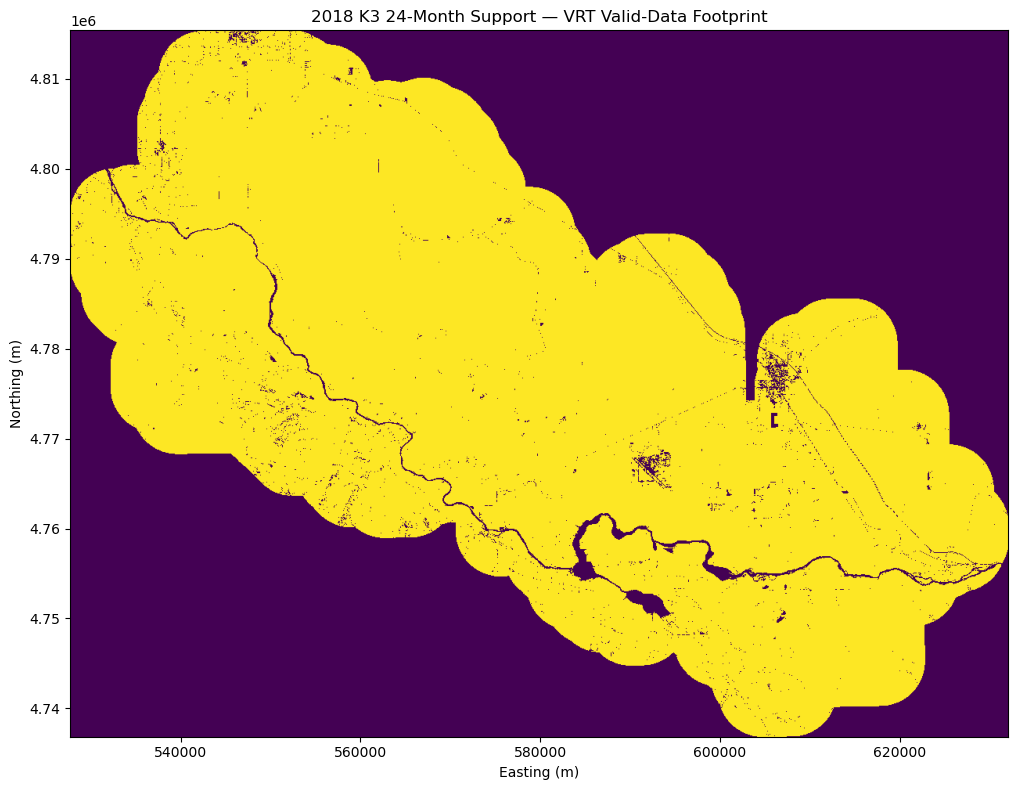

In [8]:
with rasterio.open(VRT_PATH) as src:

    display_width = 1200

    scale = display_width / src.width

    display_height = int(
        src.height * scale
    )

    # Read only the validity mask for band 1
    mask = src.read_masks(
        1,
        out_shape=(
            display_height,
            display_width
        )
    )

    valid = (
        mask > 0
    ).astype(
        np.uint8
    )

    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]


plt.figure(
    figsize=(12, 8)
)

plt.imshow(
    valid,
    extent=extent,
    origin="upper",
    vmin=0,
    vmax=1
)

plt.title(
    "2018 K3 24-Month Support — VRT Valid-Data Footprint"
)

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")

plt.tight_layout()
plt.show()

## 6. Convert sin/cos to intercept, amplitude, and phase

The source export contains raw OLS coefficients. We derive:

\[
A_h = \sqrt{\sin_h^2 + \cos_h^2}
\]

\[
\phi_h = \operatorname{atan2}(\sin_h,\cos_h)
\]

and preserve the two observation-count bands separately:

- `nobs`: valid observations during focal year 2018;
- `nobs_fit`: valid observations used across July 2017–June 2019.

`RMSE_fit_*` is fit-window RMSE and should **not** be directly compared to the original 2018-only RMSE.


In [9]:
SOURCE_LOOKUP = {
    name: i
    for i, name in enumerate(source_descriptions, start=1)
}


def build_output_schema():

    schema = []

    # Intercepts
    for variable in VARIABLES:
        schema.append({
            "name": f"constant_{variable}",
            "type": "copy",
            "source": f"constant_{variable}",
        })

    # K3 amplitude + phase
    for h in range(1, 4):

        for variable in VARIABLES:
            schema.append({
                "name": f"amp{h}_{variable}",
                "type": "amplitude",
                "sin": f"sin{h}_{variable}",
                "cos": f"cos{h}_{variable}",
            })

        for variable in VARIABLES:
            schema.append({
                "name": f"phase{h}_{variable}",
                "type": "phase",
                "sin": f"sin{h}_{variable}",
                "cos": f"cos{h}_{variable}",
            })

    # QA bands
    schema.append({
        "name": "nobs",
        "type": "copy",
        "source": "nobs",
    })

    schema.append({
        "name": "nobs_fit",
        "type": "copy",
        "source": "nobs_fit",
    })

    for variable in VARIABLES:
        schema.append({
            "name": f"RMSE_fit_{variable}",
            "type": "copy",
            "source": f"RMSE_fit_{variable}",
        })

    return schema


OUTPUT_SCHEMA = build_output_schema()

print("Output bands:", len(OUTPUT_SCHEMA))
assert len(OUTPUT_SCHEMA) == 122


Output bands: 122


In [10]:
DERIVED_TIF = (
    DERIVED_DIR
    / "2018_K3_24MonthSupport_InterceptAmpPhase_nobs_nobsfit_RMSEfit.tif"
)


def read_source_band(src, band_name, window):
    arr = src.read(
        SOURCE_LOOKUP[band_name],
        window=window,
        masked=True,
    )
    return arr


with rasterio.open(VRT_PATH) as src:

    profile = src.profile.copy()
    profile.update(
        driver="GTiff",
        count=len(OUTPUT_SCHEMA),
        dtype="float32",
        nodata=NODATA,
        compress="DEFLATE",
        predictor=3,
        tiled=True,
        blockxsize=512,
        blockysize=512,
        BIGTIFF="YES",
    )

    with rasterio.open(DERIVED_TIF, "w", **profile) as dst:

        for i, band in enumerate(OUTPUT_SCHEMA, start=1):
            dst.set_band_description(i, band["name"])

        dst.update_tags(
            focal_year="2018",
            harmonic_order="3",
            fit_start="2017-07-01",
            fit_end="2019-06-30",
            time_origin="2018-01-01",
            time_scale_days="365.25",
            fundamental_period_months="12",
            shortest_period_months="4",
            phase_units="radians",
            phase_definition="atan2(sin_coeff, cos_coeff)",
            amplitude_definition="sqrt(cos_coeff^2 + sin_coeff^2)",
            reconstruction=(
                "constant + sum(amplitude_h * "
                "cos(h*2*pi*t - phase_h))"
            ),
            nobs_definition="valid focal-year 2018 observations",
            nobs_fit_definition=(
                "valid observations used in Jul-2017 through Jun-2019 fit"
            ),
            rmse_fit_definition=(
                "RMSE over the 24-month regression support window"
            ),
        )

        windows = list(src.block_windows(1))
        n_windows = len(windows)

        for j, (_, window) in enumerate(windows, start=1):

            if j == 1 or j % 50 == 0 or j == n_windows:
                print(f"window {j:,} / {n_windows:,}")

            out_arrays = []

            for spec in OUTPUT_SCHEMA:

                if spec["type"] == "copy":

                    data = read_source_band(
                        src,
                        spec["source"],
                        window,
                    )

                    out = data.filled(NODATA).astype(np.float32)

                else:

                    sin_arr = read_source_band(
                        src,
                        spec["sin"],
                        window,
                    )

                    cos_arr = read_source_band(
                        src,
                        spec["cos"],
                        window,
                    )

                    combined_mask = (
                        np.ma.getmaskarray(sin_arr)
                        | np.ma.getmaskarray(cos_arr)
                    )

                    sin_data = sin_arr.filled(np.nan).astype(np.float32)
                    cos_data = cos_arr.filled(np.nan).astype(np.float32)

                    if spec["type"] == "amplitude":
                        calc = np.sqrt(
                            sin_data * sin_data
                            + cos_data * cos_data
                        )

                    elif spec["type"] == "phase":
                        calc = np.arctan2(
                            sin_data,
                            cos_data,
                        )

                    else:
                        raise ValueError(spec["type"])

                    calc[combined_mask] = NODATA
                    out = calc.astype(np.float32)

                out_arrays.append(out)

            dst.write(
                np.stack(out_arrays, axis=0),
                window=window,
            )

print("\nWrote:")
print(DERIVED_TIF)


window 1 / 5,084
window 50 / 5,084
window 100 / 5,084
window 150 / 5,084
window 200 / 5,084
window 250 / 5,084
window 300 / 5,084
window 350 / 5,084
window 400 / 5,084
window 450 / 5,084
window 500 / 5,084
window 550 / 5,084
window 600 / 5,084
window 650 / 5,084
window 700 / 5,084
window 750 / 5,084
window 800 / 5,084
window 850 / 5,084
window 900 / 5,084
window 950 / 5,084
window 1,000 / 5,084
window 1,050 / 5,084
window 1,100 / 5,084
window 1,150 / 5,084
window 1,200 / 5,084
window 1,250 / 5,084
window 1,300 / 5,084
window 1,350 / 5,084
window 1,400 / 5,084
window 1,450 / 5,084
window 1,500 / 5,084
window 1,550 / 5,084
window 1,600 / 5,084
window 1,650 / 5,084
window 1,700 / 5,084
window 1,750 / 5,084
window 1,800 / 5,084
window 1,850 / 5,084
window 1,900 / 5,084
window 1,950 / 5,084
window 2,000 / 5,084
window 2,050 / 5,084
window 2,100 / 5,084
window 2,150 / 5,084
window 2,200 / 5,084
window 2,250 / 5,084
window 2,300 / 5,084
window 2,350 / 5,084
window 2,400 / 5,084
window 2,450 /

## 7. Band map and final QA

In [13]:
band_map_rows = []

for i, spec in enumerate(OUTPUT_SCHEMA, start=1):

    row = {
        "band": i,
        "band_name": spec["name"],
        "product_type": spec["type"],
        "harmonic_order_model": 3,
    }

    if spec["type"] == "copy":
        row["source_band"] = spec["source"]

    else:
        row["source_sin_band"] = spec["sin"]
        row["source_cos_band"] = spec["cos"]

    band_map_rows.append(row)

band_map = pd.DataFrame(band_map_rows)

BAND_MAP_CSV = DERIVED_DIR / "2018_K3_24MonthSupport_BandMap.csv"

band_map.to_csv(BAND_MAP_CSV, index=False)

with rasterio.open(DERIVED_TIF) as src:

    assert src.count == len(band_map)
    assert list(src.descriptions) == band_map["band_name"].tolist()

    print("Final raster bands:", src.count)
    print("CRS:", src.crs)
    print("Shape:", src.height, "x", src.width)
    print("Resolution:", src.res)
    print("Nodata:", src.nodata)

print("\nBand-map QA passed.")
print(BAND_MAP_CSV)


Final raster bands: 122
CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Shape: 7857 x 10435
Resolution: (10.0, 10.0)
Nodata: -32768.0

Band-map QA passed.
A:\NCA_DATA\Validation\2018_HarmonicSensitivity\K3_24MonthSupport\Derived_AmpPhase_TIFs\2018_K3_24MonthSupport_BandMap.csv


## 8. Random valid pixel — reconstruct 2018 RGB + NDVI

The coefficients were estimated with 24 months of support, but the plotted product is restricted to the focal year **2018** (`0 ≤ t < 1`).


In [14]:
def derived_lookup(src):
    descriptions = list(src.descriptions)

    if any(d is None for d in descriptions):
        raise RuntimeError("Derived raster has unnamed bands.")

    return {
        name: i
        for i, name in enumerate(descriptions, start=1)
    }


def read_pixel(src, lookup, band_name, row, col):
    value = src.read(
        lookup[band_name],
        window=((row, row + 1), (col, col + 1)),
    )[0, 0]

    if src.nodata is not None and value == src.nodata:
        return np.nan

    return float(value)


rng = np.random.default_rng(42)

with rasterio.open(DERIVED_TIF) as src:

    lookup = derived_lookup(src)
    nobs_band = lookup["nobs"]

    # Use the focal-year eligibility band to identify candidate pixels.
    nobs = src.read(nobs_band, masked=True)

    valid = (
        ~np.ma.getmaskarray(nobs)
        & np.isfinite(nobs.data)
        & (nobs.data >= 12)
    )

    rows, cols = np.where(valid)

    chosen = rng.integers(0, len(rows))

    RANDOM_ROW = int(rows[chosen])
    RANDOM_COL = int(cols[chosen])

    RANDOM_X, RANDOM_Y = src.xy(
        RANDOM_ROW,
        RANDOM_COL,
    )

    RANDOM_NOBS = read_pixel(
        src, lookup, "nobs", RANDOM_ROW, RANDOM_COL
    )

    RANDOM_NOBS_FIT = read_pixel(
        src, lookup, "nobs_fit", RANDOM_ROW, RANDOM_COL
    )

print("Random pixel")
print("row / col:", RANDOM_ROW, RANDOM_COL)
print("X / Y:", RANDOM_X, RANDOM_Y)
print("2018 nobs:", RANDOM_NOBS)
print("24-month nobs_fit:", RANDOM_NOBS_FIT)


Random pixel
row / col: 1305 2188
X / Y: 549625.0 4802355.0
2018 nobs: 65.0
24-month nobs_fit: 134.0


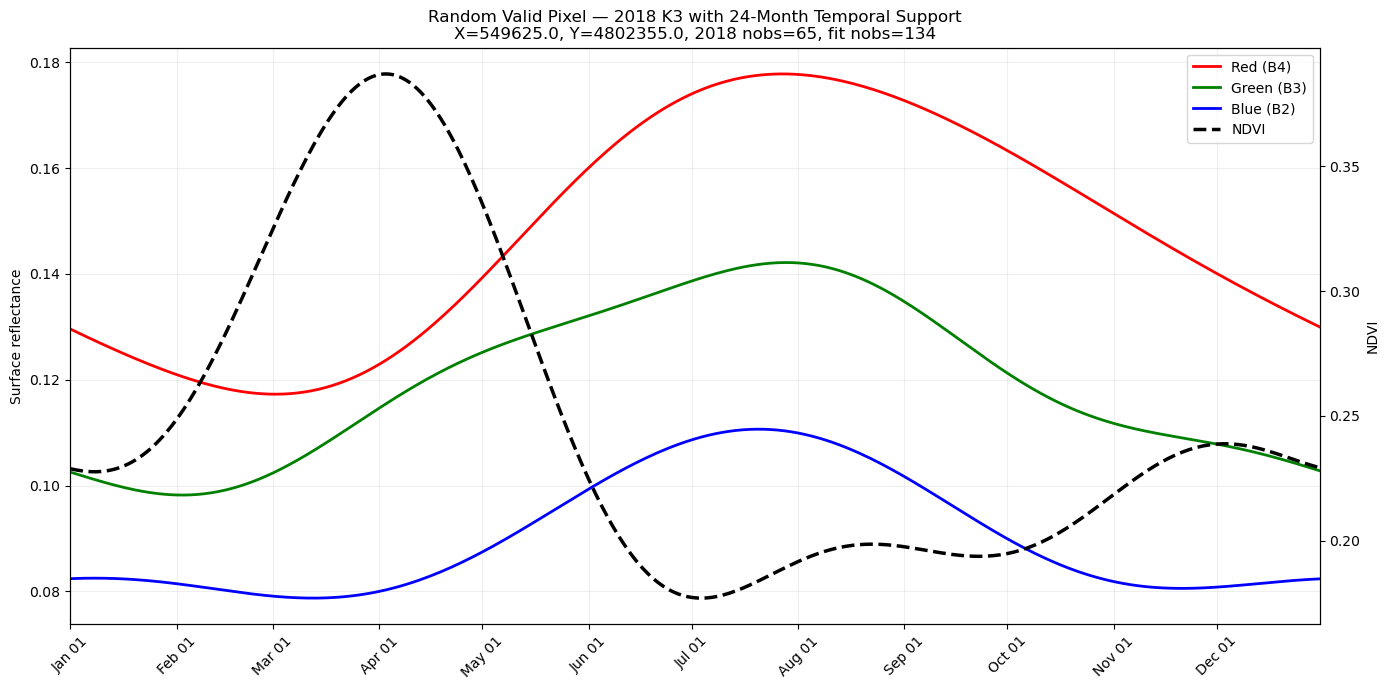

In [16]:
DATES_2018 = pd.date_range(
    "2018-01-01",
    "2018-12-31",
    freq="D",
)

T_2018 = np.arange(len(DATES_2018)) / 365.25


def reconstruct_derived_k3(
    src,
    lookup,
    variable,
    row,
    col,
):

    intercept = read_pixel(
        src,
        lookup,
        f"constant_{variable}",
        row,
        col,
    )

    curve = np.full(
        len(T_2018),
        intercept,
        dtype=float,
    )

    for h in range(1, 4):

        amplitude = read_pixel(
            src,
            lookup,
            f"amp{h}_{variable}",
            row,
            col,
        )

        phase = read_pixel(
            src,
            lookup,
            f"phase{h}_{variable}",
            row,
            col,
        )

        curve += amplitude * np.cos(
            h * 2 * np.pi * T_2018 - phase
        )

    return curve


with rasterio.open(DERIVED_TIF) as src:

    lookup = derived_lookup(src)

    curves = {
        v: reconstruct_derived_k3(
            src,
            lookup,
            v,
            RANDOM_ROW,
            RANDOM_COL,
        )
        for v in ["B4", "B3", "B2", "NDVI"]
    }


fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    DATES_2018,
    curves["B4"],
    label="Red (B4)",
    linewidth=2,
    color="red",
)

ax.plot(
    DATES_2018,
    curves["B3"],
    label="Green (B3)",
    linewidth=2,
    color="green",
)

ax.plot(
    DATES_2018,
    curves["B2"],
    label="Blue (B2)",
    linewidth=2,
    color="blue",
)

ax.set_ylabel("Surface reflectance")
ax.grid(alpha=0.2)

ax2 = ax.twinx()

ax2.plot(
    DATES_2018,
    curves["NDVI"],
    linestyle="--",
    linewidth=2.5,
    color="black",
    label="NDVI",
)

ax2.set_ylabel("NDVI")

ax.set_xlim(
    pd.Timestamp("2018-01-01"),
    pd.Timestamp("2018-12-31"),
)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.tick_params(axis="x", rotation=45)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
)

ax.set_title(
    "Random Valid Pixel — 2018 K3 with 24-Month Temporal Support\n"
    f"X={RANDOM_X:.1f}, Y={RANDOM_Y:.1f}, "
    f"2018 nobs={int(RANDOM_NOBS)}, "
    f"fit nobs={int(RANDOM_NOBS_FIT)}"
)

fig.tight_layout()
plt.show()
